In [5]:
import pandas as pd

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [6]:
print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [9]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [10]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [11]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [13]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [14]:
trades.duplicated().sum()

np.int64(0)

In [17]:
# Convert to datetime

trades["Timestamp"] = pd.to_datetime(trades["Timestamp"])

sentiment["date"] = pd.to_datetime(sentiment["date"])

In [18]:
trades["Date"] = trades["Timestamp"].dt.date

sentiment["Date"] = sentiment["date"].dt.date

In [19]:
trades[["Timestamp","Date"]].head()

,Timestamp,Date
0,1970-01-01 00:28:50,1970-01-01
1,1970-01-01 00:28:50,1970-01-01
2,1970-01-01 00:28:50,1970-01-01
3,1970-01-01 00:28:50,1970-01-01
4,1970-01-01 00:28:50,1970-01-01


In [20]:
sentiment[["date","Date"]].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [21]:
df = pd.merge(
    trades,
    sentiment[["Date","classification"]],
    on="Date",
    how="left"
)

In [23]:
df["Win"] = df["Closed PnL"] > 0

In [24]:
summary = pd.DataFrame({

    "Metric":[
        "Total Trades",
        "Unique Traders",
        "Average Profit",
        "Median Profit",
        "Maximum Profit",
        "Maximum Loss"
    ],

    "Value":[
        len(df),
        df["Account"].nunique(),
        df["Closed PnL"].mean(),
        df["Closed PnL"].median(),
        df["Closed PnL"].max(),
        df["Closed PnL"].min()
    ]

})

summary

,Metric,Value
0,Total Trades,211224.000000
1,Unique Traders,32.000000
2,Average Profit,48.749001
3,Median Profit,0.000000
4,Maximum Profit,135329.090100
5,Maximum Loss,-117990.104100


In [34]:
# Convert Timestamp IST to datetime
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

# Convert sentiment date
sentiment["date"] = pd.to_datetime(sentiment["date"])

# Create Date columns
trades["Date"] = trades["Timestamp IST"].dt.date
sentiment["Date"] = sentiment["date"].dt.date

In [35]:
df = pd.merge(
    trades,
    sentiment[["Date", "classification"]],
    on="Date",
    how="left"
)

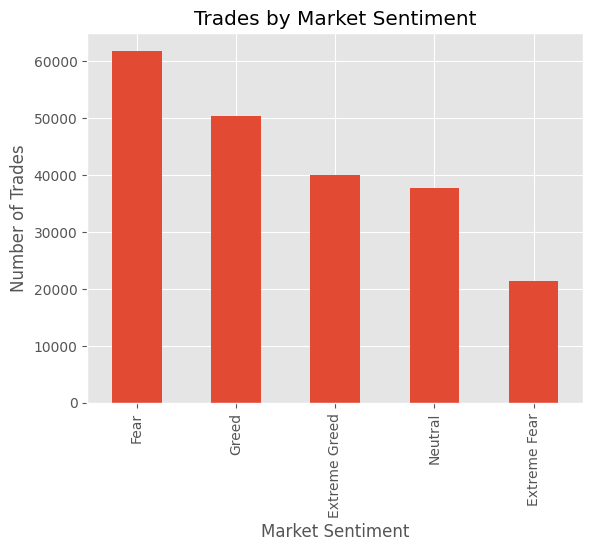

In [63]:
import matplotlib.pyplot as plt

df["classification"].value_counts().plot(kind="bar")

plt.title("Trades by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Number of Trades")
plt.savefig("Trades by market.png", dpi=300, bbox_inches="tight")

plt.show()

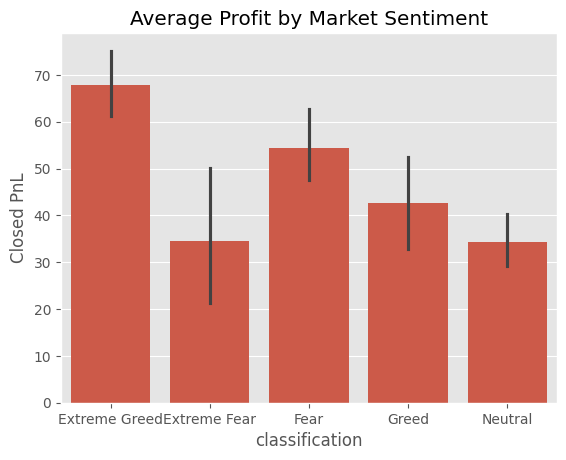

In [62]:
import seaborn as sns

sns.barplot(
    data=df,
    x="classification",
    y="Closed PnL"
)

plt.title("Average Profit by Market Sentiment")
plt.savefig("Average Profit by Market Sentiment.png", dpi=300, bbox_inches="tight")

plt.show()

In [41]:
coin_profit = (
    df.groupby("Coin")["Closed PnL"]
      .mean()
      .sort_values(ascending=False)
)

coin_profit

,Closed PnL
Coin,
@109,270.704207
AVAX,239.095613
ENA,219.524751
@85,200.804091
EIGEN,197.063189
...,...
S,-60.033651
IO,-62.198609
@147,-70.126539


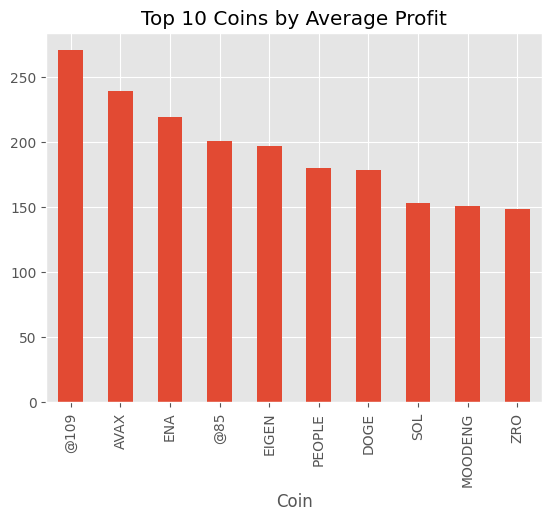

In [61]:
coin_profit.head(10).plot(kind="bar")

plt.title("Top 10 Coins by Average Profit")
plt.savefig("top 10 coin by avg profit.png", dpi=300, bbox_inches="tight")

plt.show()

In [52]:
# Create a Win column
df["Win"] = df["Closed PnL"] > 0

In [53]:
df[["Closed PnL", "Win"]].head()

,Closed PnL,Win
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False


In [54]:
df.groupby("classification")["Win"].mean() * 100

,Win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


In [43]:
pd.crosstab(
    df["Side"],
    df["classification"]
)

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
Side,,,,,
BUY,10935,17940,30270,24576,18969
SELL,10465,22052,31567,25727,18717


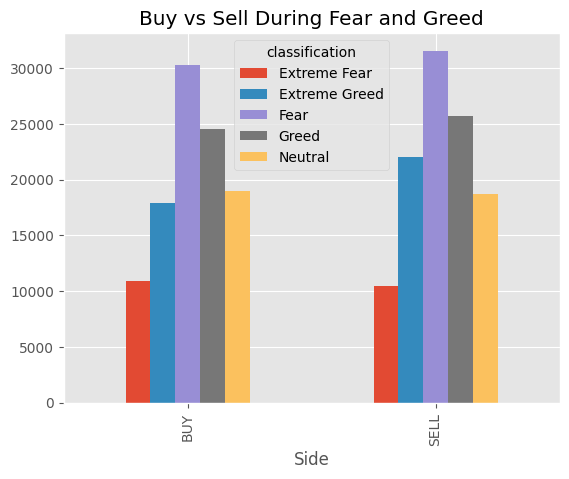

In [58]:
pd.crosstab(
    df["Side"],
    df["classification"]
).plot(kind="bar")

plt.title("Buy vs Sell During Fear and Greed")
plt.savefig("buy vs sell", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
df.groupby("classification")["Size USD"].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


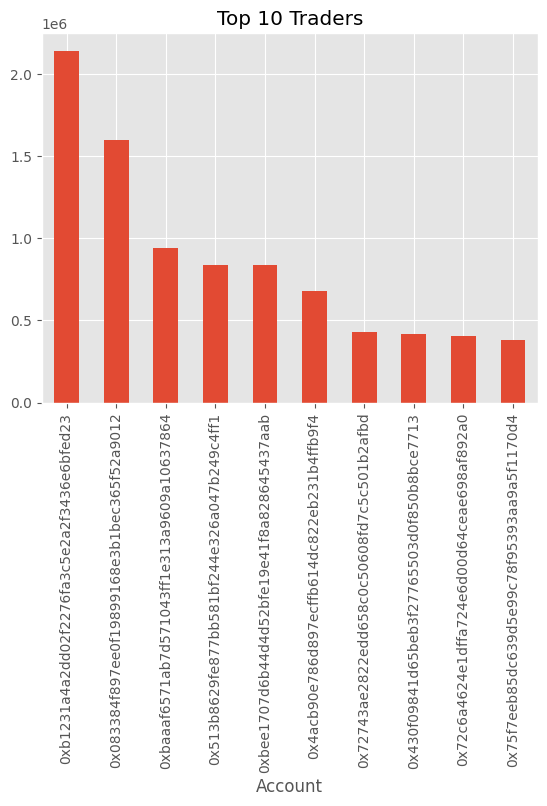

In [59]:
top = (
    df.groupby("Account")["Closed PnL"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top.plot(kind="bar")

plt.title("Top 10 Traders")
plt.savefig("top 10 traders.png", dpi=300, bbox_inches="tight")

plt.show()

In [47]:
numeric = df.select_dtypes(include="number")

numeric.corr()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID
Execution Price,1.000000,-0.017185,0.189855,0.017241,-0.006505,0.125850,0.225265,0.001841
Size Tokens,-0.017185,1.000000,0.013310,0.044660,0.005068,-0.043753,0.006710,-0.003848
Size USD,0.189855,0.013310,1.000000,0.007787,0.123589,0.045210,0.745939,0.000245
Start Position,0.017241,0.044660,0.007787,1.000000,0.004066,-0.082799,0.010559,0.001165
Closed PnL,-0.006505,0.005068,0.123589,0.004066,1.000000,-0.007250,0.084020,0.003466
Order ID,0.125850,-0.043753,0.045210,-0.082799,-0.007250,1.000000,0.039303,0.003880
Fee,0.225265,0.006710,0.745939,0.010559,0.084020,0.039303,1.000000,0.000940
Trade ID,0.001841,-0.003848,0.000245,0.001165,0.003466,0.003880,0.000940,1.000000


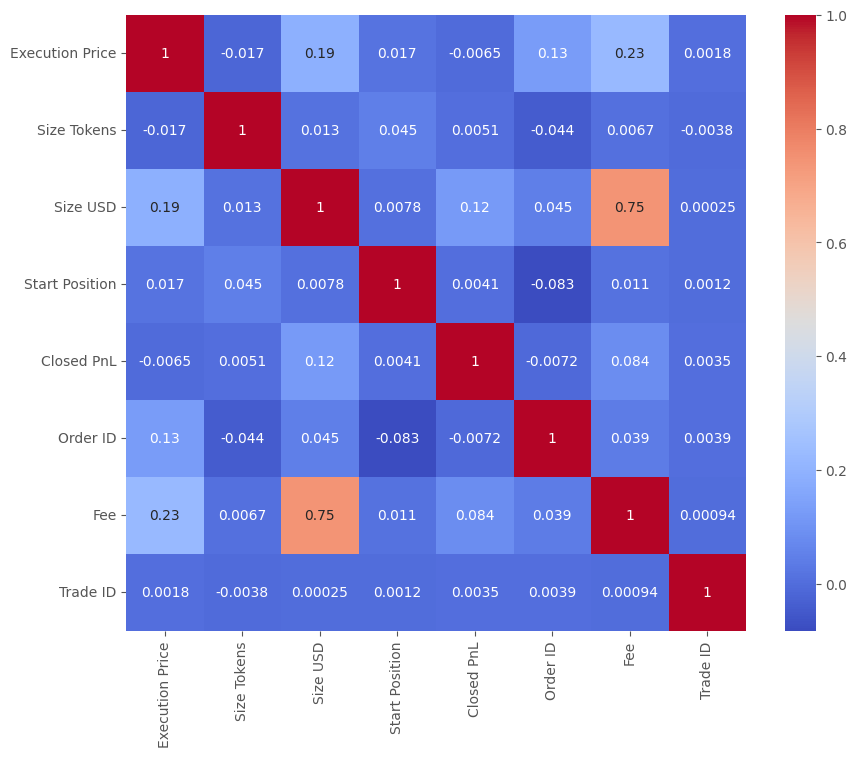

In [60]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.savefig("coolwarm.png", dpi=300, bbox_inches="tight")
plt.show()